In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:

# Loading the dataset
# https://drive.google.com/file/d/1fShBl4C0UMHnwE6tDfGTGYQ_LWZfmJwH/view?usp=sharing
file_path = 'https://drive.google.com/uc?export=download&id=1fShBl4C0UMHnwE6tDfGTGYQ_LWZfmJwH'
data = pd.read_csv(file_path)


# PLOTING THE DATASET

# PREPROCESSING


Goals:

* Understand the structure of the dataset.
* Identify missing values, anomalies, or outliers.
* Visualize relationships between features.

In [ ]:
# Displaying the first few rows
print(data.shape)
data.head()
#data.tail()

(35064, 29)


,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


Our dataset has 29 columns and 35000 row, each row represent an hourly timestamp starting from 2015/01/01 to 2018/12/31

In [ ]:
# Checking the structure of the dataset
print(data.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 29 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   time                                         35064 non-null  object 
 1   generation biomass                           35045 non-null  float64
 2   generation fossil brown coal/lignite         35046 non-null  float64
 3   generation fossil coal-derived gas           35046 non-null  float64
 4   generation fossil gas                        35046 non-null  float64
 5   generation fossil hard coal                  35046 non-null  float64
 6   generation fossil oil                        35045 non-null  float64
 7   generation fossil oil shale                  35046 non-null  float64
 8   generation fossil peat                       35046 non-null  float64
 9   generation geothermal                        35046 non-null  float64
 10

As we can see, the coulmn 9 and 23 has no values, so we need to do something about that, since there is no way we could try to forecast or generate the values, we will just drop the column

In [ ]:
# Checking for missing values
missing_values = data.isnull().sum()
print("Missing Values:\n", missing_values)

Missing Values:
 time                                               0
generation biomass                                19
generation fossil brown coal/lignite              18
generation fossil coal-derived gas                18
generation fossil gas                             18
generation fossil hard coal                       18
generation fossil oil                             19
generation fossil oil shale                       18
generation fossil peat                            18
generation geothermal                             18
generation hydro pumped storage aggregated     35064
generation hydro pumped storage consumption       19
generation hydro run-of-river and poundage        19
generation hydro water reservoir                  18
generation marine                                 19
generation nuclear                                17
generation other                                  18
generation other renewable                        18
generation solar             

In [ ]:
#data = data.drop(['forecast wind offshore eday ahead', 'generation hydro pumped storage aggregated'], axis=1)
data.shape[1]

29

For the study, most of the shown column are not related to what the goal, meaning that droping unusable columns will ease the process.

In [ ]:
# Dropping unusable columns

clean_data = data.drop(['generation fossil coal-derived gas','generation fossil oil shale',
                            'generation fossil peat', 'generation geothermal',
                            'generation hydro pumped storage aggregated', 'generation marine',
                            'generation wind offshore', 'forecast wind offshore eday ahead',
                            'forecast solar day ahead',
                            'total load forecast',
                            'forecast wind onshore day ahead'],
                            axis=1)

The range of the actual price is from

In [ ]:
# Summary statistics for numerical columns
clean_data.describe().round(2)

,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind onshore,total load actual,price day ahead,price actual
count,35045.00,35046.00,35046.00,35046.00,35045.00,35045.00,35045.00,35046.00,35047.00,35046.00,35046.00,35046.00,35045.00,35046.00,35028.00,35064.00,35064.00
mean,383.51,448.06,5622.74,4256.07,298.32,475.58,972.12,2605.11,6263.91,60.23,85.64,1432.67,269.45,5464.48,28696.94,49.87,57.88
std,85.35,354.57,2201.83,1961.60,52.52,792.41,400.78,1835.20,839.67,20.24,14.08,1680.12,50.20,3213.69,4574.99,14.62,14.20
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,18041.00,2.06,9.33
25%,333.00,0.00,4126.00,2527.00,263.00,0.00,637.00,1077.25,5760.00,53.00,73.00,71.00,240.00,2933.00,24807.75,41.49,49.35
50%,367.00,509.00,4969.00,4474.00,300.00,68.00,906.00,2164.00,6566.00,57.00,88.00,616.00,279.00,4849.00,28901.00,50.52,58.02
75%,433.00,757.00,6429.00,5838.75,330.00,616.00,1250.00,3757.00,7025.00,80.00,97.00,2578.00,310.00,7398.00,32192.00,60.53,68.01
max,592.00,999.00,20034.00,8359.00,449.00,4523.00,2000.00,9728.00,7117.00,106.00,119.00,5792.00,357.00,17436.00,41015.00,101.99,116.80


Time is considered as an object, meaning we have to convert it to proper data format.

In [ ]:
# Converting time to datetime object and set it as index

clean_data['time'] = pd.to_datetime(clean_data['time'], utc=True, infer_datetime_format=True)
clean_data = clean_data.set_index('time')

<ipython-input-9-67a91f60824a>:3: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  clean_data['time'] = pd.to_datetime(clean_data['time'], utc=True, infer_datetime_format=True)


Checking if there is any missing or NAN values.

In [ ]:
clean_data.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 35064 entries, 2014-12-31 23:00:00+00:00 to 2018-12-31 22:00:00+00:00
Data columns (total 17 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   generation biomass                           35045 non-null  float64
 1   generation fossil brown coal/lignite         35046 non-null  float64
 2   generation fossil gas                        35046 non-null  float64
 3   generation fossil hard coal                  35046 non-null  float64
 4   generation fossil oil                        35045 non-null  float64
 5   generation hydro pumped storage consumption  35045 non-null  float64
 6   generation hydro run-of-river and poundage   35045 non-null  float64
 7   generation hydro water reservoir             35046 non-null  float64
 8   generation nuclear                           35047 non-null  float64
 9   generation other         

In [ ]:

# Total number of missing values
clean_data.isnull().sum().sum()

292

In [ ]:

# Total number of duplicated values
clean_data.duplicated().sum().sum()

0

As we can see our energy dataset has no duplicated values. However, it has many null values, and as this is a time series we can not simply just drop the rows, a better solution would be to replace the values.

In [ ]:
#data = data.dropna()
#data.shape

# Total missing values for each feature
clean_data.isnull().sum()

,0
generation biomass,19
generation fossil brown coal/lignite,18
generation fossil gas,18
generation fossil hard coal,18
generation fossil oil,19
generation hydro pumped storage consumption,19
generation hydro run-of-river and poundage,19
generation hydro water reservoir,18
generation nuclear,17
generation other,18


  **Most null values can be found in the 'total load actual' column. Therefore, it is a good idea to visualize it and see what we can do. The good news is that there are no NaNs in the 'price actual' column, which we will use as the target variable in order to train our model. The similar numbers in null values in the columns which have to do with the type of energy generation probably indicate that they will also appear in the same rows. Let us first define a plot function which we will then use so as to visualize the 'total load actual' column, as well as other columns.**

In [ ]:
# Displaying the rows with null values

clean_data[clean_data.isnull().any(axis=1)]

,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind onshore,total load actual,price day ahead,price actual
time,,,,,,,,,,,,,,,,,
2015-01-05 02:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21182.0,35.20,59.68
2015-01-05 11:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.50,79.14
2015-01-05 12:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.80,73.95
2015-01-05 13:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.50,71.93
2015-01-05 14:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.00,71.50
2015-01-05 15:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.00,71.85
2015-01-05 16:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.60,80.53
2015-01-19 18:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39304.0,70.01,88.95
2015-01-19 19:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39262.0,69.00,87.94


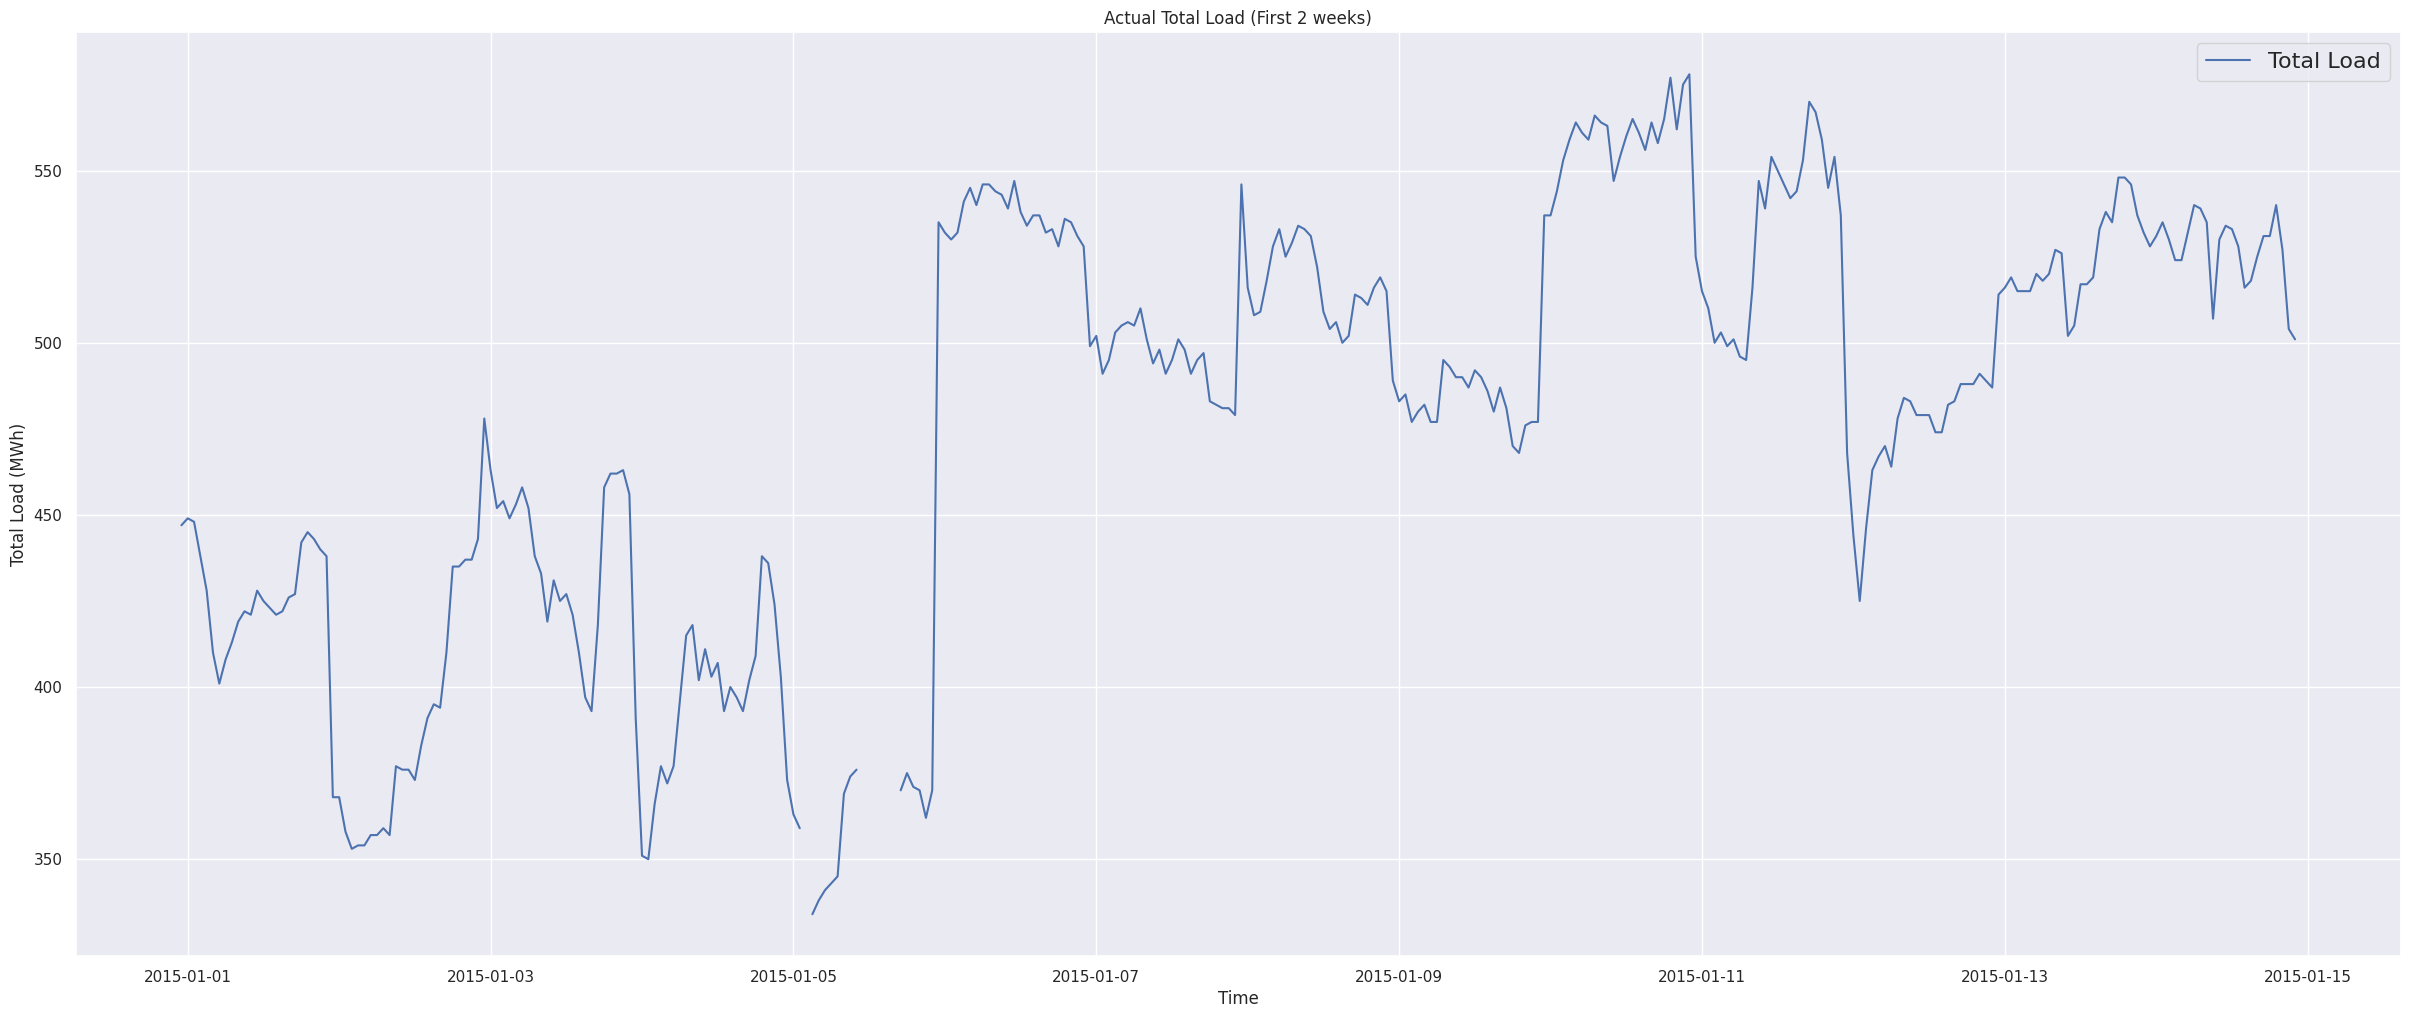

In [ ]:
sns.set()
fig, ax = plt.subplots(figsize=(30, 12))

ax.set_xlabel('Time')
ax.set_ylabel('Total Load (MWh)')
ax.set_title('Actual Total Load (First 2 weeks)')

start = 0
end = 24 * 7 * 2    # 24 hours/day * 7 days/week * 2 weeks
ax.plot(clean_data['generation biomass'][start:end], label='Total Load')

ax.legend(fontsize=16)
ax.grid(True)
plt.show()


# Filling null values using interpolation

In [ ]:
# Filling null values using interpolation
clean_data.fillna(method='ffill', inplace=True)


<ipython-input-16-05822c675bc6>:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  clean_data.fillna(method='ffill', inplace=True)


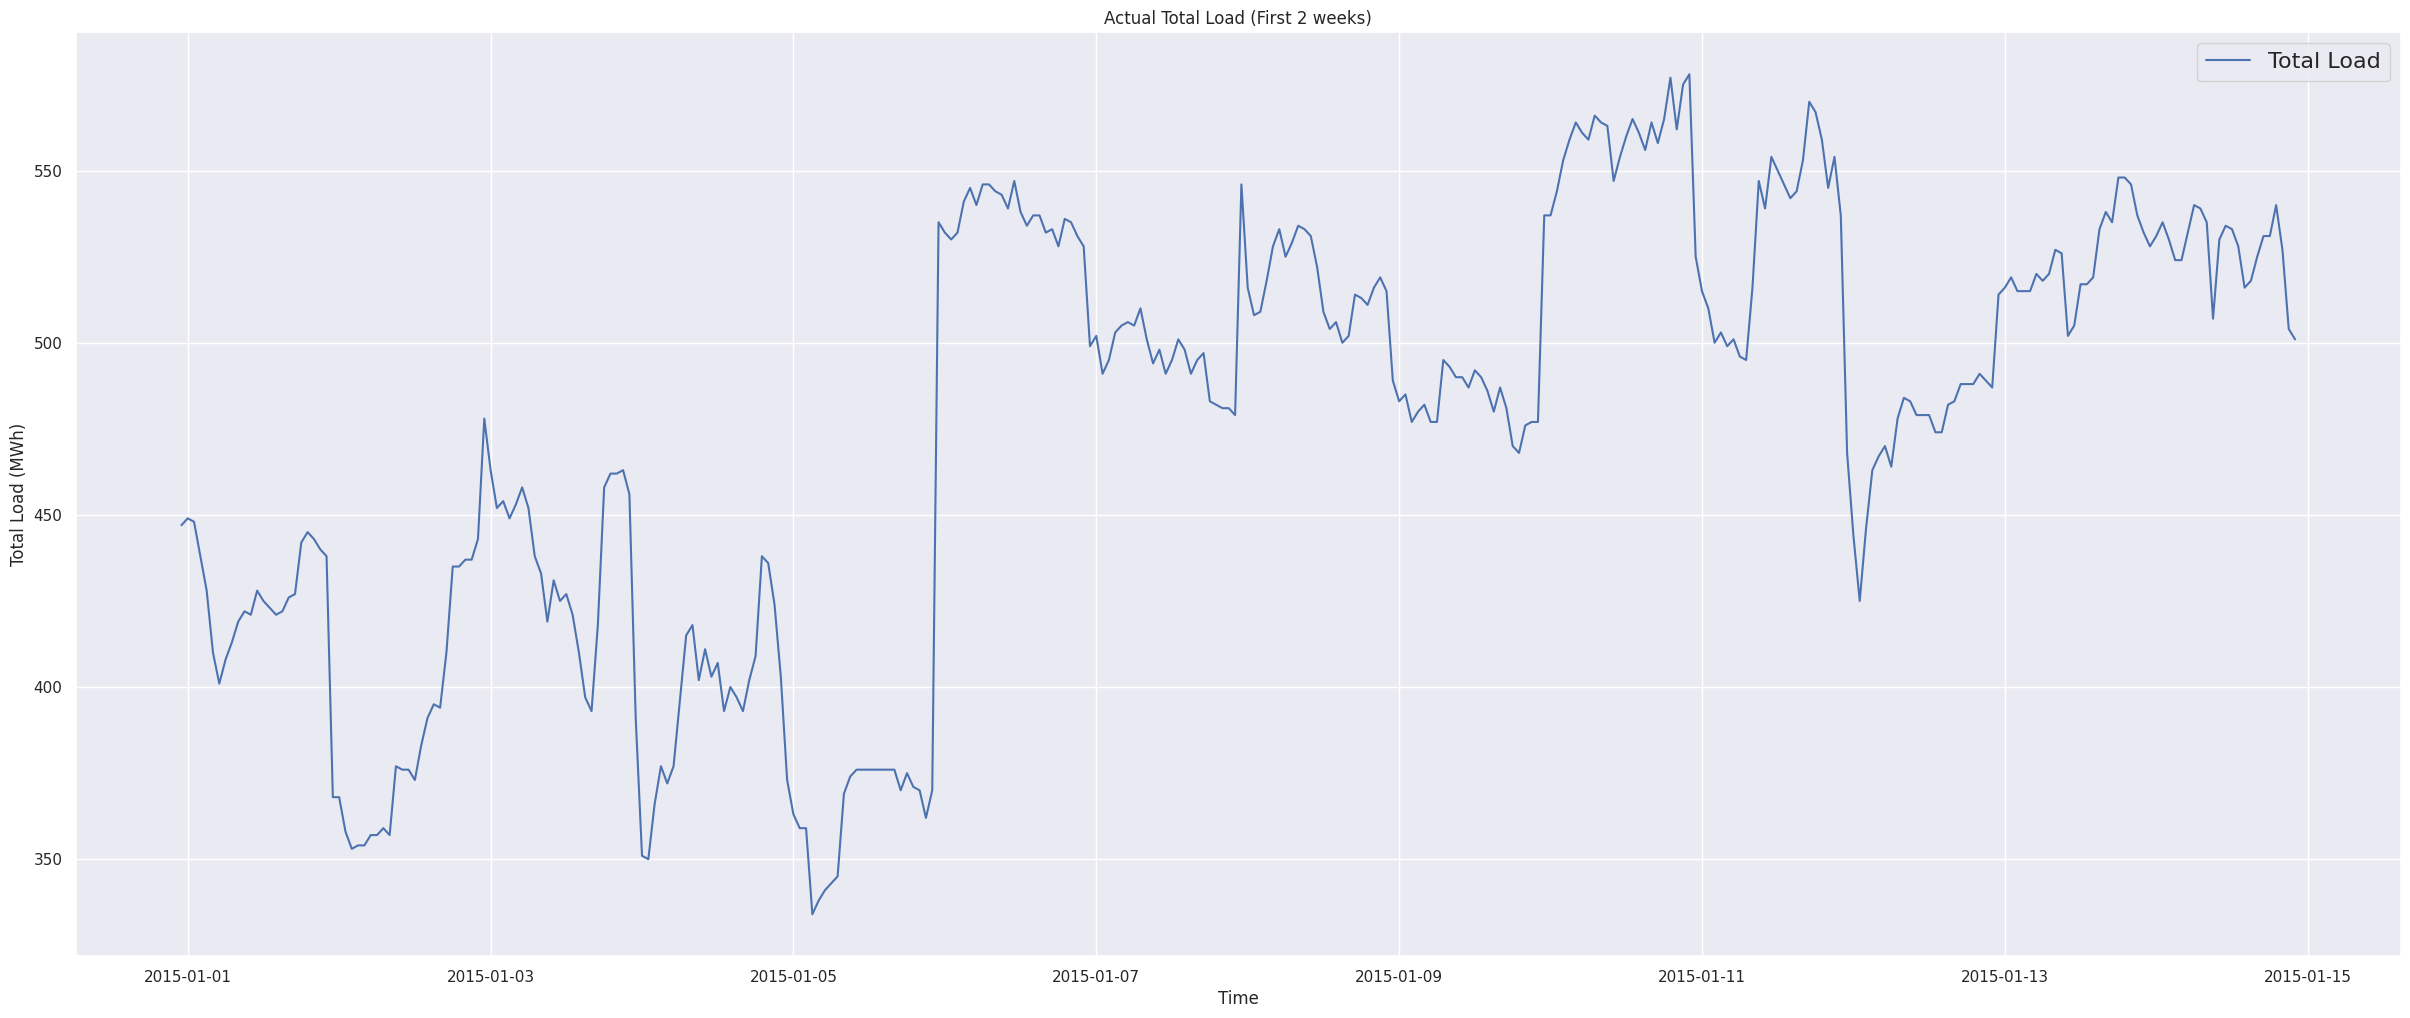

In [ ]:
sns.set()
fig, ax = plt.subplots(figsize=(30, 12))

ax.set_xlabel('Time')
ax.set_ylabel('Total Load (MWh)')
ax.set_title('Actual Total Load (First 2 weeks)')

start = 0
end = 24 * 7 * 2
ax.plot(clean_data['generation biomass'][start:end], label='Total Load')

ax.legend(fontsize=16)
ax.grid(True)
plt.show()


# **Plotting**

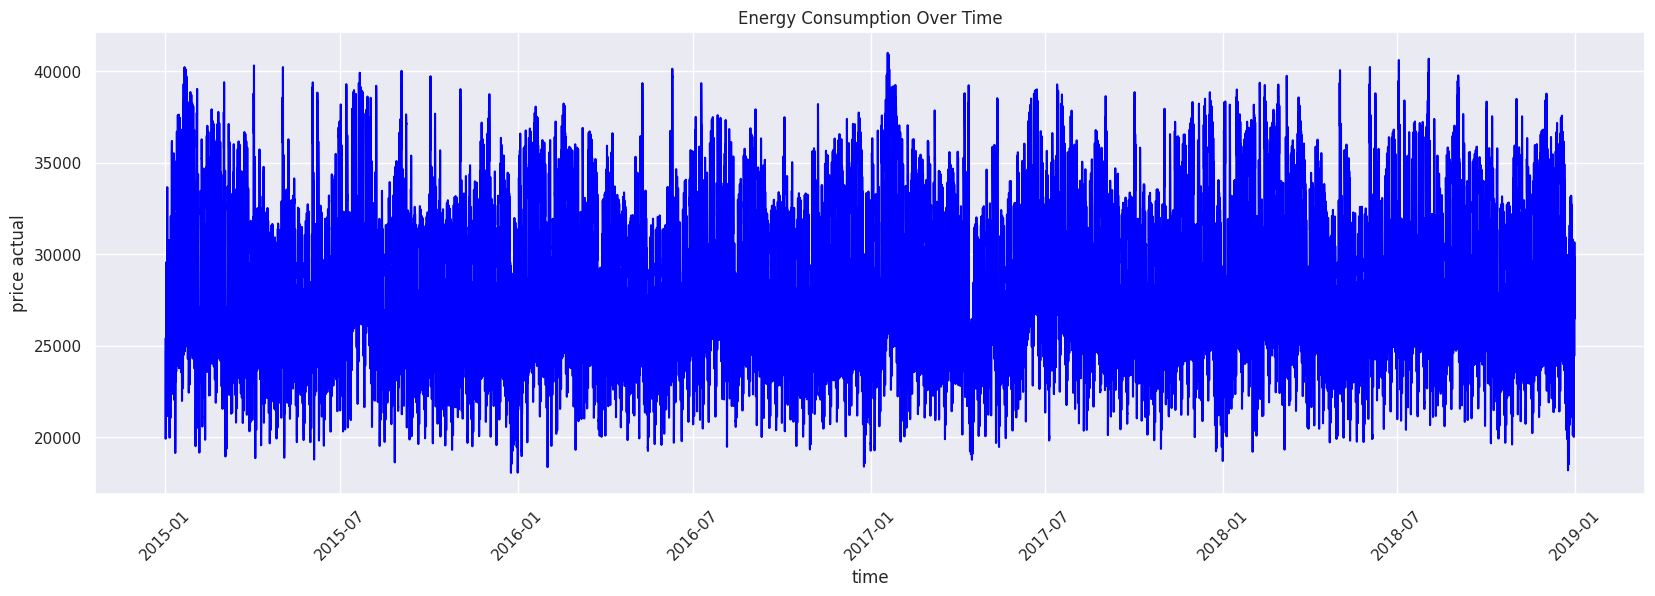

In [ ]:
plt.figure(figsize=(20, 6))
plt.plot(clean_data.index, clean_data['total load actual'], color='blue')
plt.title("Energy Consumption Over Time")
plt.xlabel("time")
plt.ylabel("price actual")
plt.xticks(rotation=45)
plt.show()

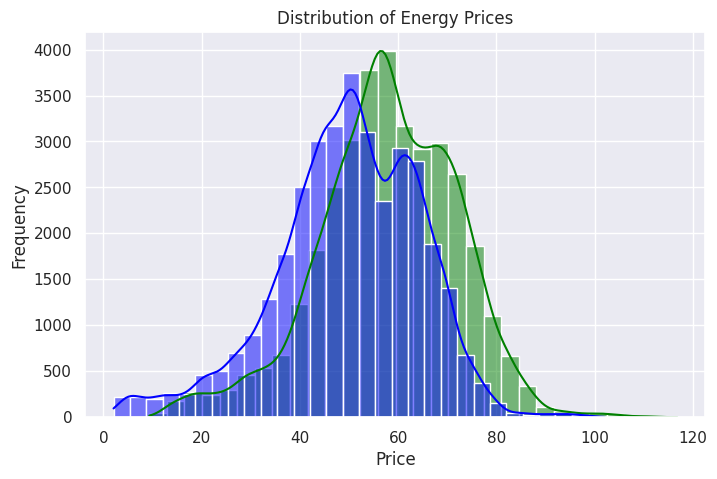

In [ ]:
plt.figure(figsize=(8, 5))

# Plot histograms with labels
sns.histplot(clean_data['price actual'], bins=30, kde=True, color='green', label='Actual Price')
sns.histplot(clean_data['price day ahead'], bins=30, kde=True, color='blue', label='Forecasted Price')

# Add title, labels, and legend
plt.title("Distribution of Energy Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


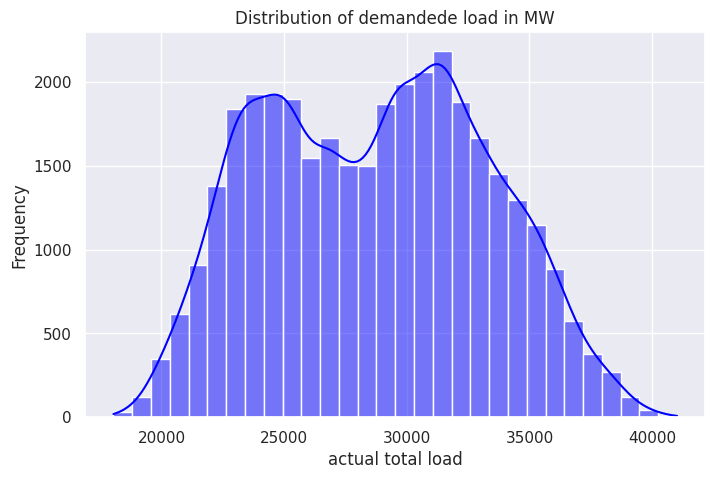

In [ ]:
plt.figure(figsize=(8, 5))

# Plot histograms with labels
#sns.histplot(clean_data['total load forecast'], bins=30, kde=True, color='green', label='total load forecast')
sns.histplot(clean_data['total load actual'], bins=30, kde=True, color='blue', label='total load')

# Add title, labels, and legend
plt.title("Distribution of demandede load in MW")
plt.xlabel("actual total load")
plt.ylabel("Frequency")
plt.show()


In [ ]:
# Save the DataFrame to a CSV file
clean_data.to_csv('energy_dataset.csv', index=True)

# Now you can download the file
from google.colab import files
files.download('energy_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>